In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import *

In [2]:
# initialize spark
spark = SparkSession.builder \
    .appName("News Data Analysis") \
    .config("spark.driver.extraJavaOptions", "-Xlog:disable") \
    .config("spark.executor.extraJavaOptions", "-Xlog:disable") \
    .getOrCreate()

# define the schema
schema = StructType([
    StructField("timestamp", IntegerType(), True),
    StructField("source", StringType(), True),
    StructField("archive", StringType(), True),
    StructField("id", IntegerType(), True),
    StructField("probability", FloatType(), True),
    StructField("keywords", MapType(StringType(), IntegerType()), True),
    StructField("sentiment", FloatType(), True),
    #StructField("status", StringType(), True),
    #StructField("error", StringType(), True)
])

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/03/30 10:44:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


**global data analysis**

In [3]:
df = spark.read.format("json").schema(schema).load("data/news/status=success")
df02 = spark.read.format("json").schema(schema).load("data/news/status=error")
df03 = spark.read.format("json").schema(schema).load("data/news/status=duplicate")
df04 = spark.read.format("json").schema(schema).load("data/news/status=notnews")

print("Total number of links taken into consideration: ", df.count() + df02.count() + df03.count() + df04.count())
print("Number of actually news: ", df.count())
print(f"which are distributed across {len(df.inputFiles())} files.")

OpenJDK 64-Bit Server VM warning: CodeCache is full. Compiler has been disabled.
OpenJDK 64-Bit Server VM warning: Try increasing the code cache size using -XX:ReservedCodeCacheSize=


CodeCache: size=131072Kb used=24445Kb max_used=24464Kb free=106626Kb
 bounds [0x000000010818c000, 0x000000010999c000, 0x000000011018c000]
 total_blobs=10183 nmethods=9264 adapters=831
 compilation: disabled (not enough contiguous free space left)


Total number of links taken into consideration:  2088500


Number of actually news:  491421
which are distributed across 3333 files.


In [4]:
df.printSchema()

root
 |-- timestamp: integer (nullable = true)
 |-- source: string (nullable = true)
 |-- archive: string (nullable = true)
 |-- id: integer (nullable = true)
 |-- probability: float (nullable = true)
 |-- keywords: map (nullable = true)
 |    |-- key: string
 |    |-- value: integer (valueContainsNull = true)
 |-- sentiment: float (nullable = true)



In [5]:
df.show(5)

+---------+----------------+--------------------+-------+-----------+--------------------+----------+
|timestamp|          source|             archive|     id|probability|            keywords| sentiment|
+---------+----------------+--------------------+-------+-----------+--------------------+----------+
|   202001|         Público|https://arquivo.p...|1835900|  0.5295997|{barba -> 2, vejo...| 0.6476388|
|   202001|Correio da Manhã|https://arquivo.p...|1837379|  0.5238493|{culpa -> 2, BBC ...|0.27266267|
|   202001|         Público|https://arquivo.p...|1835527|  0.6116205|{armar -> 2, José...| 0.6469555|
|   202001|             RTP|https://arquivo.p...|1837074| 0.65349644|{Aproveitamento H...|0.65425557|
|   202001|Correio da Manhã|https://arquivo.p...|1834367| 0.52037495|{Castigo -> 1, Di...| -0.536976|
+---------+----------------+--------------------+-------+-----------+--------------------+----------+
only showing top 5 rows



**filtering query**

benchmarking the performance of the query

with cache

```
Galp: 18.44
galp: 13.70
Millenium: 16.94
```

without cache

```
Millenium: > 31
```

In [6]:
query = "Galp"

In [7]:
from pyspark.sql import functions as F

query_col_counts = F.col("keywords").getItem(query)
df_with_query = df.filter(query_col_counts.isNotNull() & (query_col_counts > 4)).cache()

print(f"Number of news with the query: {df_with_query.count()}")

df_with_query.show(5)

Number of news with the query: 913
+---------+------------------+--------------------+-------+-----------+--------------------+----------+
|timestamp|            source|             archive|     id|probability|            keywords| sentiment|
+---------+------------------+--------------------+-------+-----------+--------------------+----------+
|   202001|     Dinheiro Vivo|https://arquivo.p...|1838114|  0.7566516|{Carlos Gomes da ...|0.61716205|
|   202001|              SAPO|https://arquivo.p...|1838321|  0.6049441|{Carlos Gomes da ...| 0.6639911|
|   201912|     Dinheiro Vivo|https://arquivo.p...|1780505| 0.65439415|{Estreia em Portu...| 0.6377338|
|   202004|Jornal de Negócios|https://arquivo.p...|2081072| 0.66854674|{Carlos Gomes da ...|0.62749356|
|   202004|  Correio da Manhã|https://arquivo.p...|2083223|   0.765813|{restrição -> 2, ...| 0.6407466|
+---------+------------------+--------------------+-------+-----------+--------------------+----------+
only showing top 5 rows



In [8]:
# Process data
result = (
    df_with_query.rdd
    .flatMap(lambda row: [
        (key, (value,
               {row["timestamp"]: value},
               row["sentiment"]*value,
               {row["source"]: 1},
               [row["archive"]])) for key, value in row["keywords"].items()
    ])
    .reduceByKey(lambda a, b: (
        a[0] + b[0],  # Sum count values
        {ts: a[1].get(ts, 0) + b[1].get(ts, 0) for ts in set(a[1]) | set(b[1])},  # Merge timestamp counts
        a[2] + b[2],  # Sum sentiment values
        {source: a[3].get(source, 0) + b[3].get(source, 0) for source in set(a[3]) | set(b[3])},  # Merge source counts
        a[4] + b[4]  # Merge archive lists
    ))
    .collect()
)

# Convert to dictionary
output = {key: {"count": value[0],
                "date": value[1],
                "sentiment": value[2]/value[0],
                "source": value[3],
                "news": value[4]} for key, value in result}

print(f"The outputs is a {type(output)} with {len(output)} topics related to {query}.")
print(f"The keys are the topics and the values are dictionaries with the following keys: {list(output.values())[0].keys()}")

The outputs is a <class 'dict'> with 22632 topics related to Galp.
The keys are the topics and the values are dictionaries with the following keys: dict_keys(['count', 'date', 'sentiment', 'source', 'news'])


In [9]:
import json

file_path = 'data/keywords_test.json'

# Save the dictionary to a JSON file
#with open(file_path, 'w') as json_file:
#    json.dump(output, json_file, indent=4)

#print(f"JSON data saved to {file_path}")

# Load the JSON data back into a Python dictionary
#with open(file_path, 'r') as json_file:
#    loaded_data = json.load(json_file)

# Print loaded data
#print("Loaded data:")
#loaded_data

**creating the graph**

just use the graph.py file to create it

the variable output is the input for the graph.py file

**query info and statistics**

- number of news (add pie plot showing % ?) [done]

In [10]:
print(f"Number of news with the query: {df_with_query.count()} out of {df.count()}, between {1900} and {2025}.")
print("Note: may replace in the future the df.count() with a fixed integer, avoiding computation.")

Number of news with the query: 913 out of 491421, between 1900 and 2025.
Note: may replace in the future the df.count() with a fixed integer, avoiding computation.


- source of news [done and implemented]

In [11]:
from pyspark.sql import functions as F
import plotly.graph_objects as go

# Group by the column and count the values
value_counts_df = df_with_query.groupBy('source').count().toPandas()

# Extract labels and values directly
labels = value_counts_df['source']
values = value_counts_df['count']

fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=values,
    hoverinfo='label+value+percent',
    hovertemplate="<b>%{label}</b><br>Notícias: %{value}<br>Percentagem: %{percent:.2%}<extra></extra>"
)])

fig.update_traces(
    textposition='inside',
    textinfo='label',
    textfont_size=12
)

fig.update_layout(
    showlegend=False,
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(t=25, b=25, l=0, r=0)
)

fig.show(
    config={'displayModeBar': False}
)

- number of news and top10 words by month

In [12]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import collect_list
import pandas as pd
import plotly.express as px

traducao_meses = {
    "January": "Janeiro", "February": "Fevereiro", "March": "Março",
    "April": "Abril", "May": "Maio", "June": "Junho",
    "July": "Julho", "August": "Agosto", "September": "Setembro",
    "October": "Outubro", "November": "Novembro", "December": "Dezembro"
}

news_by_month = (
    df_with_query
    .groupBy('timestamp')
    .agg(F.count('archive').alias('count_of_news'))
    .toPandas()
)

keywords_by_month = (
    df_with_query
    .select('*', F.explode('keywords'))
    .groupBy("timestamp", "key")
    .agg(F.sum("value").alias("key_mentions"))
    .filter(F.col("key") != query)
    .withColumn("rank", F.row_number().over(Window.partitionBy("timestamp").orderBy(F.desc("key_mentions"))))
    .filter(F.col("rank") <= 5)
    .groupBy("timestamp")
    .agg(collect_list("key").alias("top5_keywords"))
    .toPandas()
)



news_history = news_by_month.merge(keywords_by_month, on="timestamp", how="inner")
news_history["timestamp"] = pd.to_datetime(news_history["timestamp"].astype(str), format='%Y%m')

min_date = news_history["timestamp"].min()
max_date = news_history["timestamp"].max()
full_range = pd.date_range(start=min_date, end=max_date, freq='MS')

news_history = news_history.set_index("timestamp").reindex(full_range).fillna(0).reset_index()
news_history = news_history.rename(columns={"index": "timestamp"})
news_history = news_history.sort_values(by="timestamp")

news_history["data_formatada"] = news_history["timestamp"].dt.strftime("%B de %Y").replace(traducao_meses, regex=True)
news_history["top5_keywords"] = news_history["top5_keywords"].apply(
    lambda words: "-" if words == 0 else "<br>".join([f"{i+1}. {word}" for i, word in enumerate(words)])
)

print(news_history.columns)

# Create Plotly figure
fig = px.line(
    news_history,
    x="timestamp",
    y="count_of_news",
    line_shape="linear",
    custom_data=news_history[["data_formatada", "top5_keywords"]],
)

fig.update_traces(
    hovertemplate="<b>Data:</b> %{customdata[0]}<br>"
                  "<b>📊 Notícias:</b> %{y}<br>"
                  "<b>Top 5 Tópicos:</b><br>%{customdata[1]}"
)

fig.update_layout(
    xaxis_title="Data",
    yaxis_title="Quantidade de Notícias",
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="pink",
     margin=dict(t=0, b=0, l=0, r=0)
)

fig.update_traces(line=dict(color='rgb(255, 255, 0)'),
                  hoverlabel=dict(bgcolor='rgb(0, 255, 0)',
                                  font=dict(color='black')))


fig.update_xaxes(tickformat="%m/%Y")

# Show figure
fig.show()

Index(['timestamp', 'count_of_news', 'top5_keywords', 'data_formatada'], dtype='object')


- wordcloud

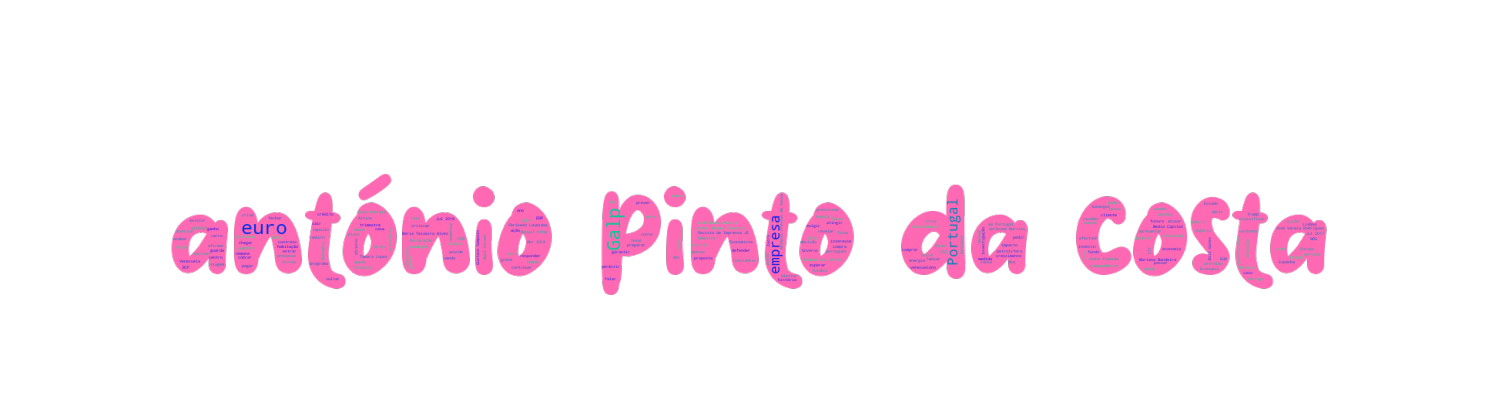

In [13]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load word count data
word_counts = {key: value["count"] for key, value in output.items()}  # Ensure this is defined

# Constants
IMAGE_SIZE = (1920, 500)  # Fixed background size (canvas)
TEXT = "antónio pinto da costa"
FONT_PATH = "assets/LoveDays-2v7Oe.ttf"
MAX_FONT_SIZE = 500  # Max possible font size

# Load font
font = ImageFont.truetype(FONT_PATH, size=MAX_FONT_SIZE)

def get_optimal_font_size(text, font_path, max_size, image_size):
    """Determine the best font size to fit within the image."""
    for size in range(max_size, 5, -5):  # Step down in increments
        font = ImageFont.truetype(font_path, size=size)
        temp_img = Image.new("RGBA", image_size, (0, 0, 0, 0))
        draw = ImageDraw.Draw(temp_img)
        bbox = draw.textbbox((0, 0), text, font=font)
        text_width, text_height = bbox[2] - bbox[0], bbox[3] - bbox[1]

        if text_width <= image_size[0] * 0.8 and text_height <= image_size[1] * 1:  
            return font, bbox  # Fit within 80% width & 50% height

    return font, bbox  # Return the smallest size if no fit

# Get optimal font size
font, bbox = get_optimal_font_size(TEXT, FONT_PATH, MAX_FONT_SIZE, IMAGE_SIZE)

# Calculate centered position
text_width, text_height = bbox[2] - bbox[0], bbox[3] - bbox[1]
x_offset = (IMAGE_SIZE[0] - text_width) // 2
y_offset = (IMAGE_SIZE[1] - text_height) // 2

# Create fixed-size image (1920x1080)
final_img = Image.new("RGBA", IMAGE_SIZE, (0, 0, 0, 0))
draw = ImageDraw.Draw(final_img)

# Draw centered text
draw.text((x_offset, y_offset), TEXT, fill=(255, 105, 180), font=font)  # Pink text

# Generate mask for WordCloud (ensure proper alpha channel handling)
mask = np.array(final_img.convert("L"))  # Convert to grayscale to use as a mask

# Generate WordCloud
wc = WordCloud(
    width=IMAGE_SIZE[0], height=IMAGE_SIZE[1],
    background_color=None, min_font_size=5, mode="RGBA",
    colormap="winter", mask=~mask, contour_color="black"
).generate_from_frequencies(word_counts)

# Convert WordCloud to image
wc_image = wc.to_image()

# Merge word cloud and text
final_img = Image.alpha_composite(final_img, wc_image)

# Show final image
plt.figure(figsize=(IMAGE_SIZE[0] / 100, IMAGE_SIZE[1] / 100))  # Adjust figure size
plt.imshow(final_img)
plt.axis("off")  # Hide axes
plt.show()

- search for a specific word

In [14]:
search_topic = "EDP"

In [15]:
print(f"Number of news where both {query} and {search_topic} are mentioned: {output[search_topic]['count']}")

Number of news where both Galp and EDP are mentioned: 1600


In [118]:
# date
from pyspark.sql import functions as F
import pandas as pd
import plotly.graph_objects as go

query = "Galp"
search_topic = "EDP"

#traducao_meses = {
#    "January": "Janeiro", "February": "Fevereiro", "March": "Março",
#    "April": "Abril", "May": "Maio", "June": "Junho",
#    "July": "Julho", "August": "Agosto", "September": "Setembro",
#    "October": "Outubro", "November": "Novembro", "December": "Dezembro"
#}

# number of news per month
news_by_month = (
    df_with_query
    .groupBy('timestamp')
    .agg(F.count('archive').alias('count_of_news'))
    .toPandas()
)
news_by_month["timestamp"] = pd.to_datetime(news_by_month["timestamp"].astype(str), format='%Y%m')

# number of mentions of the specific keyword
specific_keyword = pd.DataFrame(list(output[search_topic]["date"].items()), columns=["date", "count_specific_keyword"])
specific_keyword["date"] = pd.to_datetime(specific_keyword["date"], format="%Y%m")

# merge the two dataframes
news_history = news_by_month.merge(specific_keyword, left_on="timestamp", right_on="date", how="left")

# create full data range
min_date = news_history["timestamp"].min()
max_date = news_history["timestamp"].max()
full_range = pd.date_range(start=min_date, end=max_date, freq='MS')
news_history = news_history.set_index("timestamp").reindex(full_range).fillna(0).reset_index()
news_history = news_history.rename(columns={"index": "timestamp"})
news_history = news_history.sort_values(by="timestamp")

#news_history["data_formatada"] = news_history["timestamp"].dt.strftime("%B de %Y").replace(traducao_meses, regex=True)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=news_history["timestamp"],
    y=news_history["count_of_news"],
    mode="lines",
    name=f"Notícias sobre {query}",
    hovertemplate="%{y}"
))

fig.add_trace(go.Scatter(
    x=news_history["timestamp"],
    y=news_history["count_specific_keyword"],
    mode="lines",
    name=f"Menções de {search_topic} em notícias sobre {query}",
    hovertemplate="%{y}"
))

fig.update_layout(
    xaxis_title="Data",
    yaxis_title="Contagem",
    hovermode="x unified",
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    margin=dict(t=0, b=0, l=0, r=0),
    xaxis=dict(
        showgrid=False,
        zeroline=True,
        zerolinecolor="black",
        linecolor="black",
        linewidth=2
    ),
    yaxis=dict(
        range=[0, max(news_history["count_of_news"].max(), news_history["count_specific_keyword"].max()) * 1.1],
        showgrid=True,  
        gridcolor="lightgray",  
        zeroline=True,
        zerolinecolor="black",
        linecolor="black",
        linewidth=2
    ),
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor="rgba(255,255,255,1)",
        bordercolor="black",
        borderwidth=1
    ),
)

fig.data[0].update(line=dict(color='rgba(101, 110, 242, 0.3)'))
fig.data[1].update(line=dict(color='rgb(101, 110, 242)'))

fig.update_xaxes(tickformat="%m/%Y")

fig.show(config={'displayModeBar': False})

In [41]:
"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Sentiment Indicator</title>
    <style>
        .bar-container {
            position: relative;
            width: 300px;
            height: 20px;
            background: linear-gradient(to right, red, grey, green);
            border-radius: 5px;
            margin: 20px;
        }
        .arrow {
            position: absolute;
            top: 25px;
            left: 50%; /* Default position, will be adjusted with JS */
            transform: translateX(-50%);
            font-size: 20px;
        }
    </style>
</head>
<body>
    <div class="bar-container" id="bar">
        <div class="arrow" id="arrow">▼</div>
    </div>
    <script>
        function updateSentiment(sentiment) {
            let percentage = ((sentiment + 1) / 2) * 100; // Convert range (-1 to 1) to (0% to 100%)
            document.getElementById("arrow").style.left = percentage + "%";
        }
        
        updateSentiment({{ output[search_topic]["sentiment"] }}); // Example: Update sentiment position
    </script>
</body>
</html>
"""

output[search_topic]["sentiment"]

0.3777086667716503

In [ ]:
from pyspark.sql import functions as F
import plotly.graph_objects as go

# Group by the column and count the values
sources = output[search_topic]['source']

# Extract labels and values directly
labels = list(sources.keys())
values = list(sources.values())

fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=values,
    hoverinfo='label+value+percent',
    hovertemplate="<b>%{label}</b><br>Notícias: %{value}<br>Percentagem: %{percent:.2%}<extra></extra>"
)])

fig.update_traces(
    textposition='inside',
    textinfo='label',
    textfont_size=12
)

fig.update_layout(
    showlegend=False,
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(t=25, b=25, l=0, r=0)
)

fig.show(
    config={'displayModeBar': False}
)

In [19]:
# news